<a href="https://colab.research.google.com/github/xwx-codingweb/XIA_DSPN_S26/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds


## 1. Data, Plotting, and Train/Test Sets (2 pts)
-----
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [ ]:
install.packages("class")

In [3]:
# INSERT CODE HERE
library(class)
library(tidyverse)

d <- diamonds

d$price_bin <- ifelse(d$price > mean(d$price), 1, 0)
d$price_bin <- as.factor(d$price_bin)

d <- d %>% select(carat, depth, table, x, y, price_bin)

head(d)
dim(d)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

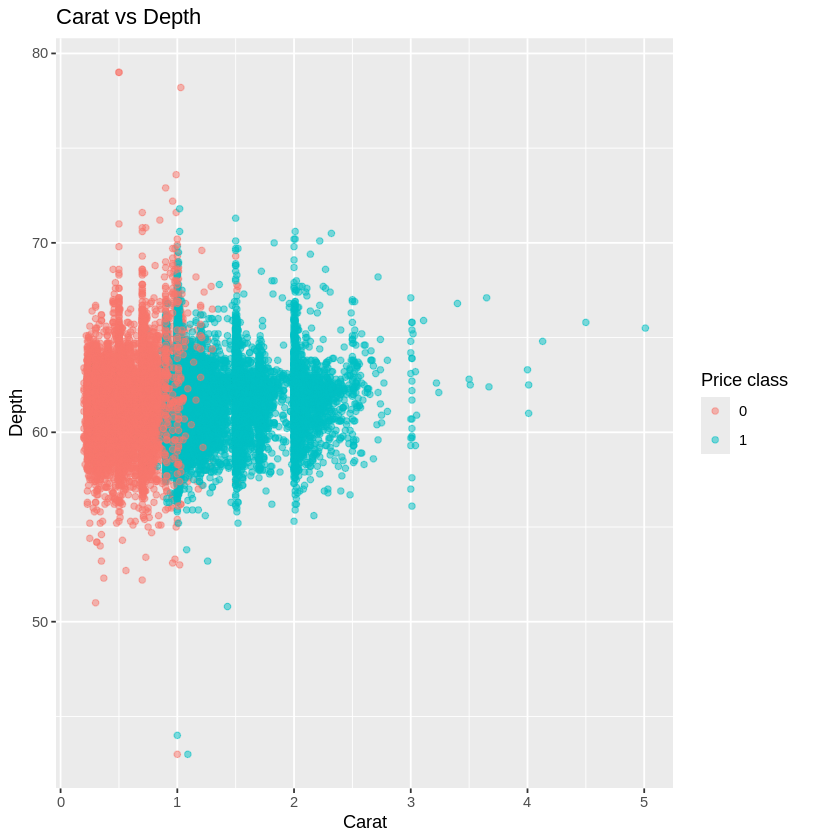

In [4]:
# INSERT CODE HERE
ggplot(d, aes(x = carat, y = depth, color = price_bin)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Carat vs Depth",
    x = "Carat",
    y = "Depth",
    color = "Price class"
  )

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> Diamonds with larger carat values tend to belong to the higher price category, while depth does not show a strong separation between the two price groups.

> Therefore, kNN may perform reasonably well. And carat provides more information about the price class.


### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [5]:
set.seed(2023)

# INSERT CODE HERE

# sample 70% for training
train_index <- sample(1:nrow(d), 0.7 * nrow(d))

train <- d[train_index, ]
test  <- d[-train_index, ]

head(train)
head(test)

# check dimensions
dim(train)
dim(test)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.22,62.3,56.0,6.81,6.84,1
1.57,62.3,56.0,7.48,7.41,1
1.11,62.4,57.7,6.57,6.64,1
0.42,60.6,57.0,4.82,4.85,0
0.32,62.6,55.0,4.39,4.36,0
0.90,62.7,58.0,6.06,6.15,1


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0.23,61.5,55,3.95,3.98,0
0.26,61.9,55,4.07,4.11,0
0.22,65.1,61,3.87,3.78,0
0.23,62.8,56,3.93,3.90,0
0.31,62.2,54,4.35,4.37,0
0.20,60.2,62,3.79,3.75,0


[1] 37758     6

[1] 16182     6

## 2: KNN (3 points)
----
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [6]:
set.seed(2023)
# INSERT CODE HERE

knn_pred <- knn(
  train = train[, c("carat", "depth")],
  test  = test[, c("carat", "depth")],
  cl    = train$price_bin,
  k = 3
)

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [7]:
# INSERT CODE HERE
conf_mat <- table(Predicted = knn_pred, Actual = test$price_bin)

conf_mat

error_rate <- mean(knn_pred != test$price_bin)

error_rate

         Actual
Predicted    0    1
        0 9756  302
        1  542 5582

[1] 0.05215672

How did your model perform?
> The model performs moderately well but makes errors.


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [8]:
set.seed(2023)
# INSERT CODE HERE

knn_pred2 <- knn(
  train = train[, c("carat","depth","table","x","y")],
  test  = test[, c("carat","depth","table","x","y")],
  cl = train$price_bin,
  k = 3
)

conf_mat2 <- table(Predicted = knn_pred2, Actual = test$price_bin)

conf_mat2

error_rate2 <- mean(knn_pred2 != test$price_bin)

error_rate2

         Actual
Predicted    0    1
        0 9782  367
        1  516 5517

[1] 0.0545668

Did your model predictions improve?
> Nope. Some of the added variables may contain redundant information and not really relate to the price category.


# 3: for loop (3 points)
----

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [11]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [12]:
for (k in seq(1:30)) {

  knn_fits <- knn(
    train = train[, c("carat","depth")],
    test  = test[, c("carat","depth")],
    cl = train$price_bin,
    k = k
  )

  conf_df <- data.frame(
    pred = knn_fits,
    actual = test$price_bin
  )

  output$error[k] <- mean(conf_df$pred != conf_df$actual)
}

head(output)

,k,error
,<int>,<dbl>
1,1,0.05407243
2,2,0.05363985
3,3,0.05234211
4,4,0.05160054
5,5,0.05135336
6,6,0.05141515


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


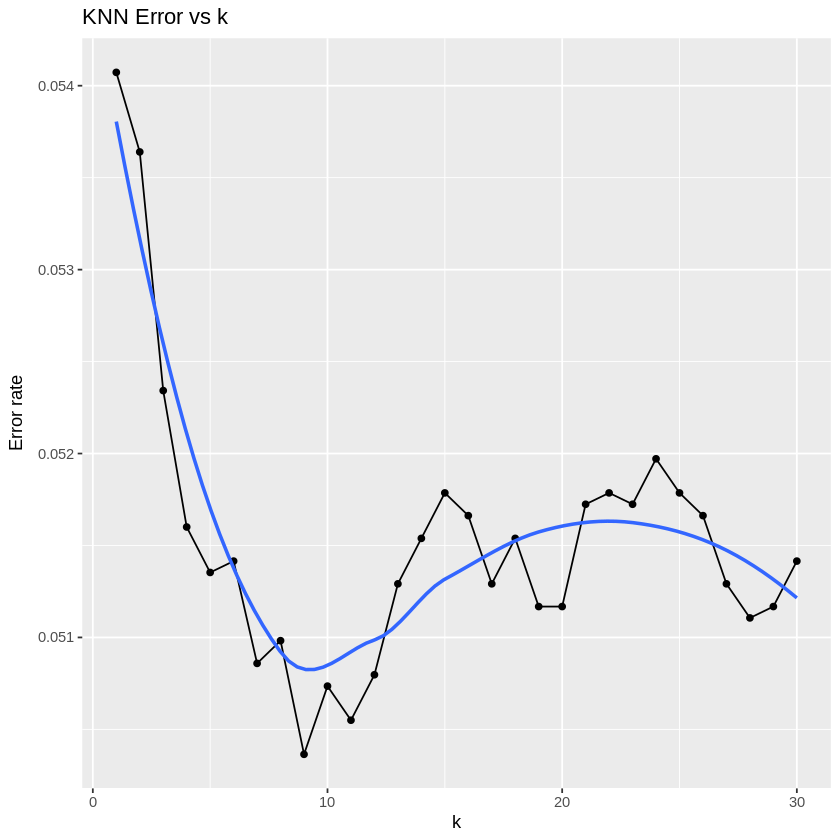

In [13]:
# INSERT CODE HERE
ggplot(output, aes(x = k, y = error)) +
  geom_line() +
  geom_point() +
  geom_smooth(se = FALSE) +
  labs(
    title = "KNN Error vs k",
    x = "k",
    y = "Error rate"
  )

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> The plot shows that error initially decreases as k increases and then increases again.

> The best value of k appears around the point where the error reaches its minimum on the plot, which is k = 9.

> Not that much improvement, I would say :(

# 4: Standardizing predictors (2)
-----

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [14]:
set.seed(2023)
#INSERT CODE HERE

train_scaled <- train
test_scaled  <- test

train_scaled[, c("carat","depth")] <- scale(train[, c("carat","depth")])
test_scaled[, c("carat","depth")]  <- scale(test[, c("carat","depth")])

best_k <- output$k[which.min(output$error)]

knn_scaled <- knn(
  train = train_scaled[, c("carat","depth")],
  test  = test_scaled[, c("carat","depth")],
  cl = train_scaled$price_bin,
  k = best_k
)

conf_scaled <- table(Predicted = knn_scaled, Actual = test_scaled$price_bin)

conf_scaled

scaled_error <- mean(knn_scaled != test_scaled$price_bin)

scaled_error

         Actual
Predicted    0    1
        0 9764  268
        1  534 5616

[1] 0.04956124

What impact did rescaling the data have on your error rate?
> Rescaling the predictors improves the model performance slightly.

> Because KNN relies on distance calculations, variables with larger scales can dominate the distance metric.

> Standardizing ensures that both predictors contribute equally to the distance calculations, which leads to better classification accuracy :)


**DUE:** 5pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>
